## Drone Rescue Environment Implementation

**Configuration for Group ID 149 (treated under 5-9 setting):**

Using the assignment's 59-style configuration and odd-ending battery rule:

*   **Grid Size:** 6x6
*   **Rescue Targets:** 3
*   **Charging Stations:** 2
*   **Danger Zones:** 4
*   **Blocked Cells:** 3
*   **Maximum Battery:** 15 units (group ID ends with odd digit 9)
*   **Wind Probability:** 30% (0.3)
*   **Maximum Steps:** 75 (for 6x6 grid)

The starting position (S) is fixed at (0,0) as per the problem statement.

In [34]:
# Import necessary libraries
import numpy as np
import random
from collections import defaultdict

# --- Constants for Actions ---
UP = 0
DOWN = 1
LEFT = 2
RIGHT = 3
HOVER = 4

ACTIONS = [UP, DOWN, LEFT, RIGHT, HOVER]
ACTION_NAMES = {UP: "Up", DOWN: "Down", LEFT: "Left", RIGHT: "Right", HOVER: "Hover"}

# --- Constants for Cell Types ---
FREE = 'F'
DANGER = 'D'
RESCUE = 'R'
CHARGE = 'C'
WIND = 'W'
BLOCKED = 'X'
START = 'S'

# --- Visual Labels (assignment letters) ---
ZONE_ICONS = {
    START: "S",
    FREE: "F",
    DANGER: "D",
    RESCUE: "R",
    CHARGE: "C",
    WIND: "W",
    BLOCKED: "X",
}
DRONE_ICON = "DR"

# --- Reward Structure ---
REWARD_RESCUE = 20
REWARD_DANGER = -10
REWARD_BATTERY_EXHAUSTED = -20
REWARD_CHARGING_STATION = 5
REWARD_MOVEMENT = -1

# --- Environment Parameters (group ID 149 -> 5-9 configuration and odd-ending battery rule) ---
GRID_SIZE = (6, 6)
MAX_BATTERY = 15
WIND_PROB = 0.3
MAX_STEPS = 75 # For 6x6 grid

In [35]:
class DroneRescueEnv:
    """
    Drone Rescue MDP environment (Group ID 149, 5-9 configuration).

    Charging station reward design note:
    The +5 reward for 'Reach charging station' is given only when the drone
    genuinely needed to recharge (battery after consuming 1 unit is below the
    CHARGE_REWARD_THRESHOLD). This prevents an unintended exploit where the
    optimal policy oscillates indefinitely at a charger rather than rescuing
    targets, which would arise if +5 were given on every entry regardless of
    battery level. The battery is always fully restored on entry regardless.
    """

    CHARGE_REWARD_THRESHOLD_OFFSET = 5  # Keep as-is per user request

    def __init__(self, grid_size=GRID_SIZE, max_battery=MAX_BATTERY, wind_prob=WIND_PROB, max_steps=MAX_STEPS):
        self.grid_size = grid_size
        self.rows, self.cols = grid_size
        self.max_battery = max_battery
        self.wind_prob = wind_prob
        self.max_steps = max_steps
        self.current_step = 0
        self._charge_reward_threshold = max_battery - self.CHARGE_REWARD_THRESHOLD_OFFSET

        self.start_pos = (0, 0) # Fixed at top-left corner
        self.initial_grid_config = self._generate_initial_grid_config()
        self.grid = None
        self.state = None
        self.all_possible_states = []
        self.reset()

    def _generate_initial_grid_config(self):
        # 6x6 grid: 3 rescue targets, 2 charging stations, 4 danger zones, 3 blocked cells.
        grid_cells = [
            [START, FREE,  WIND,   FREE,   FREE,   RESCUE],
            [FREE,  DANGER, FREE,   BLOCKED,FREE,   FREE],
            [FREE,  CHARGE, FREE,   DANGER, FREE,   WIND],
            [FREE,  FREE,   RESCUE, FREE,   BLOCKED,FREE],
            [WIND,  DANGER, FREE,   CHARGE, FREE,   RESCUE],
            [FREE,  FREE,   DANGER, FREE,   BLOCKED,FREE]
        ]
        if grid_cells[self.start_pos[0]][self.start_pos[1]] != START:
            grid_cells[self.start_pos[0]][self.start_pos[1]] = START
        return np.array(grid_cells)

    def _get_state_tuple(self, pos, battery, rescued_targets):
        return (pos[0], pos[1], battery, tuple(rescued_targets))

    def reset(self):
        self.grid = np.copy(self.initial_grid_config)
        self.current_pos = self.start_pos
        self.battery = self.max_battery
        self.current_step = 0
        self.rescue_target_locations = [
            (r, c) for r in range(self.rows) for c in range(self.cols)
            if self.grid[r, c] == RESCUE
        ]
        self.rescued_targets = [False] * len(self.rescue_target_locations)
        self.state = self._get_state_tuple(self.current_pos, self.battery, self.rescued_targets)
        return self.state

    def _get_next_position(self, current_pos, action):
        r, c = current_pos
        dr, dc = 0, 0
        if action == UP:    dr = -1
        elif action == DOWN:  dr = 1
        elif action == LEFT:  dc = -1
        elif action == RIGHT: dc = 1
        new_r, new_c = r + dr, c + dc
        if not (0 <= new_r < self.rows and 0 <= new_c < self.cols):
            return current_pos, False
        if self.initial_grid_config[new_r, new_c] == BLOCKED:
            return current_pos, False
        return (new_r, new_c), True

    def get_valid_actions(self, state):
        """Return valid actions available from a given state."""
        r, c, battery, rescued_targets_tuple = state
        if battery <= 0 or all(rescued_targets_tuple):
            return []

        valid_actions = [HOVER]
        for action in [UP, DOWN, LEFT, RIGHT]:
            _, is_valid_move = self._get_next_position((r, c), action)
            if is_valid_move:
                valid_actions.append(action)
        return valid_actions

    def step(self, action):
        self.current_step += 1
        reward = REWARD_MOVEMENT
        done = False
        info = {}
        original_pos = self.current_pos

        # 1. Consume 1 battery for any action
        self.battery -= 1
        if self.battery <= 0:
            reward += REWARD_BATTERY_EXHAUSTED
            done = True
            info['reason'] = 'battery_exhausted'
            self.state = self._get_state_tuple(self.current_pos, 0, self.rescued_targets)
            return self.state, reward, done, info

        # 2. Handle Hover
        if action == HOVER:
            if self.grid[original_pos[0], original_pos[1]] == CHARGE:
                # Gain +2 battery; cancel movement cost only when actively gaining charge
                if self.battery < self.max_battery:
                    self.battery += 2
                    self.battery = min(self.battery, self.max_battery)
                    reward += 1  # cancel -1 movement cost while battery is increasing
            next_pos = original_pos
        else:
            # 3. Movement with optional wind disturbance
            if self.grid[original_pos[0], original_pos[1]] == WIND and random.random() < self.wind_prob:
                wind_action = random.choice([UP, DOWN, LEFT, RIGHT])
                next_pos, _ = self._get_next_position(original_pos, wind_action)
                info['wind_effect'] = f'Wind: {ACTION_NAMES[action]}->{ACTION_NAMES[wind_action]}'
            else:
                next_pos, _ = self._get_next_position(original_pos, action)
            self.current_pos = next_pos

        # 4. Apply cell effects at new position
        cell_type = self.grid[self.current_pos[0], self.current_pos[1]]

        if cell_type == CHARGE and original_pos != self.current_pos:
            # Keep charging-reward logic unchanged per user request.
            if self.battery < self._charge_reward_threshold:
                reward += REWARD_CHARGING_STATION
            self.battery = self.max_battery

        if cell_type == RESCUE:
            for i, loc in enumerate(self.rescue_target_locations):
                if loc == self.current_pos and not self.rescued_targets[i]:
                    self.rescued_targets[i] = True
                    reward += REWARD_RESCUE
                    self.grid[self.current_pos[0], self.current_pos[1]] = FREE
                    info['rescued'] = True
                    break

        if cell_type == DANGER:
            reward += REWARD_DANGER
            info['entered_danger'] = True

        if all(self.rescued_targets):
            done = True
            info['reason'] = 'all_rescued'
        elif self.current_step >= self.max_steps:
            done = True
            info['reason'] = 'max_steps_exceeded'

        self.state = self._get_state_tuple(self.current_pos, self.battery, self.rescued_targets)
        return self.state, reward, done, info

    def render(self):
        print(f"--- Step: {self.current_step}, Battery: {self.battery}/{self.max_battery} ---")
        print("Legend: S Start | F Free | D Danger | R Rescue | C Charge | W Wind | X Blocked | DR Drone")

        for r in range(self.rows):
            row_icons = []
            for c in range(self.cols):
                if (r, c) == self.current_pos:
                    row_icons.append(DRONE_ICON)
                else:
                    cell = self.grid[r, c]
                    row_icons.append(ZONE_ICONS.get(cell, cell))
            print(" ".join(row_icons))

        rescued_status = " ".join(["R" if s else "_" for s in self.rescued_targets])
        print(f"Rescued Targets: [{rescued_status}]")
        print("------------------------------------")

    def get_all_possible_states(self):
        """Enumerate only reachable states from the initial state."""
        if not self.all_possible_states:
            start_state = self._get_state_tuple(
                self.start_pos,
                self.max_battery,
                tuple([False] * len(self.rescue_target_locations))
            )

            visited = set([start_state])
            frontier = [start_state]

            while frontier:
                s = frontier.pop()
                if self.is_terminal_state(s):
                    continue

                for a in self.get_valid_actions(s):
                    for _, ns, _ in self.get_transition_model(s, a):
                        if ns not in visited:
                            visited.add(ns)
                            frontier.append(ns)

            self.all_possible_states = sorted(list(visited))
        return self.all_possible_states

    def is_terminal_state(self, state):
        _, _, battery, rescued_targets_tuple = state
        return battery <= 0 or all(rescued_targets_tuple)

    def get_transition_model(self, state, action):
        """Returns list of (probability, next_state, reward) for DP."""
        r, c, battery, rescued_targets_tuple = state
        current_pos = (r, c)
        current_rescued = list(rescued_targets_tuple)

        if self.is_terminal_state(state):
            return [(1.0, state, 0)]

        next_battery = battery - 1
        reward = REWARD_MOVEMENT

        if next_battery <= 0:
            next_state = self._get_state_tuple(current_pos, 0, rescued_targets_tuple)
            return [(1.0, next_state, reward + REWARD_BATTERY_EXHAUSTED)]

        transitions = []

        # --- HOVER ---
        if action == HOVER:
            next_pos = current_pos
            if self.initial_grid_config[r, c] == CHARGE:
                if next_battery < self.max_battery:
                    next_battery = min(battery + 2, self.max_battery)
                    reward += 1  # cancel movement cost while actively gaining charge
            next_state = self._get_state_tuple(next_pos, next_battery, current_rescued)
            transitions.append((1.0, next_state, reward))

        # --- MOVEMENT ---
        else:
            if self.initial_grid_config[r, c] == WIND:
                intended_prob = 1.0 - self.wind_prob
                rnd_prob = self.wind_prob / 4.0
                n_int, _ = self._get_next_position(current_pos, action)
                self._add_transition(transitions, n_int, next_battery, current_rescued, reward, intended_prob, current_pos)
                for wa in [UP, DOWN, LEFT, RIGHT]:
                    n_w, _ = self._get_next_position(current_pos, wa)
                    self._add_transition(transitions, n_w, next_battery, current_rescued, reward, rnd_prob, current_pos)
            else:
                nxt, _ = self._get_next_position(current_pos, action)
                self._add_transition(transitions, nxt, next_battery, current_rescued, reward, 1.0, current_pos)

        # Consolidate duplicate next-states
        conso = defaultdict(lambda: {'prob': 0.0, 'rwd': 0.0})
        for prob, ns, rwd in transitions:
            conso[ns]['prob'] += prob
            conso[ns]['rwd'] += prob * rwd
        return [(d['prob'], ns, d['rwd'] / d['prob']) for ns, d in conso.items()]

    def _add_transition(self, tlist, next_pos, next_battery, current_rescued, base_reward, prob, original_pos):
        tr = base_reward
        rescued = list(current_rescued)
        cell = self.initial_grid_config[next_pos[0], next_pos[1]]

        if cell == CHARGE and next_pos != original_pos:
            # Keep charging-reward logic unchanged per user request.
            if next_battery < self._charge_reward_threshold:
                tr += REWARD_CHARGING_STATION
            next_battery = self.max_battery

        if cell == RESCUE:
            for i, loc in enumerate(self.rescue_target_locations):
                if loc == next_pos and not rescued[i]:
                    rescued[i] = True
                    tr += REWARD_RESCUE
                    break

        if cell == DANGER:
            tr += REWARD_DANGER

        tlist.append((prob, self._get_state_tuple(next_pos, next_battery, rescued), tr))

### Environment Test (Optional)

Here's a small demonstration of the environment to check its basic functionality. You can run this cell to see how the drone moves and interacts with the grid.

In [50]:
# Optional: Test the environment
if __name__ == '__main__':
    env = DroneRescueEnv()
    state = env.reset()
    env.render()

    # Example actions (you can modify this sequence)
    # Try to rescue the first target, then charge, then the second
    action_sequence = [
        RIGHT, DOWN, RIGHT, RIGHT, # Towards first rescue
        HOVER, # Test hover
        DOWN, LEFT, LEFT, # Towards charging station
        HOVER, HOVER, HOVER, # Charge up
        UP, RIGHT, RIGHT, DOWN, # Towards second rescue
        HOVER # Test hover
    ]

    total_reward = 0
    done = False
    for i, action in enumerate(action_sequence):
        if done: break
        print(f"Taking action: {ACTION_NAMES[action]}")
        state, reward, done, info = env.step(action)
        total_reward += reward
        env.render()
        print(f"Reward: {reward}, Total Reward: {total_reward}, Done: {done}, Info: {info}")

    if not done:
        print("Episode ended due to max steps or unfinished. Current State:", state)
    else:
        print("Episode finished successfully. Final State:", state)

--- Step: 0, Battery: 15/15 ---
Legend: S Start | F Free | D Danger | R Rescue | C Charge | W Wind | X Blocked | DR Drone
DR F W F F R
F D F X F F
F C F D F W
F F R F X F
W D F C F R
F F D F X F
Rescued Targets: [_ _ _]
------------------------------------
Taking action: Right
--- Step: 1, Battery: 14/15 ---
Legend: S Start | F Free | D Danger | R Rescue | C Charge | W Wind | X Blocked | DR Drone
S DR W F F R
F D F X F F
F C F D F W
F F R F X F
W D F C F R
F F D F X F
Rescued Targets: [_ _ _]
------------------------------------
Reward: -1, Total Reward: -1, Done: False, Info: {}
Taking action: Down
--- Step: 2, Battery: 13/15 ---
Legend: S Start | F Free | D Danger | R Rescue | C Charge | W Wind | X Blocked | DR Drone
S F W F F R
F DR F X F F
F C F D F W
F F R F X F
W D F C F R
F F D F X F
Rescued Targets: [_ _ _]
------------------------------------
Reward: -11, Total Reward: -12, Done: False, Info: {'entered_danger': True}
Taking action: Right
--- Step: 3, Battery: 12/15 ---
Legend:

## Dynamic Programming: Value Iteration

Value Iteration algorithm to find the optimal value function $V^*(s)$ and optimal policy $\pi^*(s)$ for the `DroneRescueEnv`.

**Key parameters for Value Iteration:**
*   **Discount Factor (gamma, $\gamma$):** 0.95 (a common choice for MDPs)
*   **Stopping Threshold (theta, $\theta$):** $10^{-3}$ (as specified in the problem statement)

This implementation will iterate through all possible states, calculate the expected value of each action, and update the state's value function until the change in values falls below the specified threshold.

In [40]:
import time

# --- Value Iteration Parameters ---
GAMMA = 0.95  # Discount factor
THETA = 1e-3  # Stopping threshold

def value_iteration(env, gamma=GAMMA, theta=THETA):
    print(f"Starting Value Iteration with gamma={gamma}, theta={theta}")
    start_time = time.time()

    # Get reachable states from the environment
    all_states = env.get_all_possible_states()
    num_states = len(all_states)

    # Map state tuples to integer indices for easier lookup
    state_to_idx = {state: i for i, state in enumerate(all_states)}
    idx_to_state = {i: state for i, state in enumerate(all_states)}

    # Initialize value function V(s) to zeros for all states
    V = np.zeros(num_states)

    # Initialize policy to an empty dictionary
    policy = {}

    # Store number of iterations for analysis
    iterations = 0
    max_delta = float('inf')

    while max_delta > theta:
        max_delta = 0
        iterations += 1
        new_V = np.copy(V)

        for i, s in enumerate(all_states):
            if env.is_terminal_state(s):
                new_V[i] = 0 # Value of terminal states is 0
                continue

            valid_actions = env.get_valid_actions(s)
            if not valid_actions:
                new_V[i] = 0
                continue

            # Calculate V(s) only over valid actions
            q_values = {}

            for a in valid_actions:
                transitions = env.get_transition_model(s, a)
                expected_value = 0
                for prob, next_s, r in transitions:
                    next_s_idx = state_to_idx.get(next_s, -1)
                    if next_s_idx == -1:
                        expected_value += prob * (r + gamma * 0)
                    else:
                        expected_value += prob * (r + gamma * V[next_s_idx])
                q_values[a] = expected_value

            best_q_value = max(q_values.values())
            max_delta = max(max_delta, abs(new_V[i] - best_q_value))
            new_V[i] = best_q_value

        V = new_V

        if iterations % 10 == 0:
            print(f"Iteration {iterations}: Max Delta = {max_delta:.6f}")

    # --- Policy Extraction (after V has converged) ---
    for i, s in enumerate(all_states):
        if env.is_terminal_state(s):
            policy[s] = -1 # No action in terminal state
            continue

        valid_actions = env.get_valid_actions(s)
        if not valid_actions:
            policy[s] = -1
            continue

        q_values = {}
        for a in valid_actions:
            transitions = env.get_transition_model(s, a)
            expected_value = 0
            for prob, next_s, r in transitions:
                next_s_idx = state_to_idx.get(next_s, -1)
                if next_s_idx == -1:
                    expected_value += prob * (r + gamma * 0)
                else:
                    expected_value += prob * (r + gamma * V[next_s_idx])
            q_values[a] = expected_value

        best_action = max(q_values, key=q_values.get)
        policy[s] = best_action

    end_time = time.time()
    runtime = end_time - start_time

    print(f"Value Iteration converged in {iterations} iterations with final delta {max_delta:.6f} in {runtime:.2f} seconds.")

    return V, policy, state_to_idx, idx_to_state, iterations, runtime, max_delta


# --- Run Value Iteration ---
if __name__ == '__main__':
    env_dp = DroneRescueEnv()
    optimal_V, optimal_policy, state_to_idx, idx_to_state, vi_iterations, vi_runtime, vi_final_delta = value_iteration(env_dp)

    print("\nOptimal Value Function (V*): Sample states and their values")
    sample_states = random.sample(list(optimal_policy.keys()), min(10, len(optimal_policy.keys())))
    for s in sample_states:
        s_idx = state_to_idx[s]
        print(f"State: {s} -> Value: {optimal_V[s_idx]:.2f}")

    print("\nOptimal Policy (pi*): Sample states and their actions")
    for s in sample_states:
        action = optimal_policy[s]
        action_name = ACTION_NAMES.get(action, "TERMINAL")
        print(f"State: {s} -> Action: {action_name}")

Starting Value Iteration with gamma=0.95, theta=0.001
Iteration 10: Max Delta = 11.311318
Iteration 20: Max Delta = 0.025586
Value Iteration converged in 27 iterations with final delta 0.000650 in 1.42 seconds.

Optimal Value Function (V*): Sample states and their values
State: (3, 2, 9, (True, True, False)) -> Value: 18.19
State: (3, 1, 3, (True, False, True)) -> Value: 20.20
State: (2, 2, 14, (False, False, False)) -> Value: 41.63
State: (3, 5, 8, (False, True, False)) -> Value: 30.46
State: (2, 0, 4, (False, True, True)) -> Value: 13.00
State: (4, 0, 5, (False, False, True)) -> Value: 18.83
State: (3, 3, 4, (False, False, False)) -> Value: 46.12
State: (3, 3, 14, (False, False, False)) -> Value: 41.63
State: (3, 2, 2, (False, True, False)) -> Value: -20.95
State: (4, 2, 6, (False, True, True)) -> Value: 13.06

Optimal Policy (pi*): Sample states and their actions
State: (3, 2, 9, (True, True, False)) -> Action: Down
State: (3, 1, 3, (True, False, True)) -> Action: Up
State: (2, 2, 1

## Policy Visualization

To visualize the optimal policy $\pi^*(s)$, we will create a function that displays the grid and indicates the optimal action for the drone at each cell position, for a fixed battery level and a fixed set of rescued targets. This will help us understand the drone's preferred movements, charging behavior, and avoidance of danger zones.

For simplicity, we will visualize the policy for the following fixed state parameters:
*   **Battery Level:** `MAX_BATTERY` (fully charged)
*   **Rescued Targets:** `(False, False, False)` (no targets rescued yet)

This will show the drone's initial strategy when fully charged and needing to rescue all targets.

In [52]:
def visualize_policy(env, optimal_policy, fixed_battery, fixed_rescued_targets):
    print(f"\n--- Optimal Policy Visualization ---")
    print(f"Fixed Battery: {fixed_battery}/{env.max_battery}, Rescued Targets: {fixed_rescued_targets}")
    print("Legend: S Start | F Free | D Danger | R Rescue | C Charge | W Wind | X Blocked")

    policy_grid = np.full(env.grid_size, '', dtype=object)
    action_symbols = {UP: '↑', DOWN: '↓', LEFT: '←', RIGHT: '→', HOVER: '○', -1: '-'}

    for r in range(env.rows):
        for c in range(env.cols):
            current_pos = (r, c)
            if env.initial_grid_config[r, c] == BLOCKED:
                policy_grid[r, c] = BLOCKED
                continue

            s = env._get_state_tuple(current_pos, fixed_battery, fixed_rescued_targets)
            if s in optimal_policy:
                action = optimal_policy[s]
                policy_grid[r, c] = action_symbols.get(action, '?')
            else:
                policy_grid[r, c] = action_symbols[-1] if env.is_terminal_state(s) else '?'

    print("\nPolicy (letter + arrow):\n")
    for r in range(env.rows):
        row_str = ""
        for c in range(env.cols):
            cell_content = env.initial_grid_config[r, c]
            policy_action = policy_grid[r, c]

            if cell_content == BLOCKED:
                display_val = "X"
            else:
                zone_label = ZONE_ICONS.get(cell_content, cell_content)
                display_val = f"{zone_label}{policy_action}"

            row_str += f"{display_val:<4}"
        print(row_str)

# --- Run Policy Visualization ---
if __name__ == '__main__':
    fixed_battery_level = env_dp.max_battery
    num_targets = len(env_dp.rescue_target_locations)
    fixed_rescued_status = tuple([False] * num_targets)
    visualize_policy(env_dp, optimal_policy, fixed_battery_level, fixed_rescued_status)


--- Optimal Policy Visualization ---
Fixed Battery: 15/15, Rescued Targets: (False, False, False)
Legend: S Start | F Free | D Danger | R Rescue | C Charge | W Wind | X Blocked

Policy (letter + arrow):

S↓  F→  W→  F→  F→  R↑  
F↓  D→  F↓  X   F↑  F↑  
F↓  C↓  F↓  D↓  F↑  W↑  
F→  F→  R↑  F←  X   F↓  
W↑  D↑  F↑  C↑  F→  R→  
F↑  F←  D↑  F↑  X   F↑  


In [53]:
if __name__ == '__main__':
    # Ensure env_dp and optimal_policy are defined, as they would be from the Value Iteration cell
    try:
        env_dp # Check if it exists
        optimal_policy # Check if it exists
    except NameError:
        print("Running DroneRescueEnv and Value Iteration setup again...")
        env_dp = DroneRescueEnv()
        optimal_V, optimal_policy, state_to_idx, idx_to_state, vi_iterations, vi_runtime, vi_final_delta = value_iteration(env_dp)

    fixed_battery_level = env_dp.max_battery # Fully charged
    num_targets = len(env_dp.rescue_target_locations)
    fixed_rescued_status = tuple([False] * num_targets) # No targets rescued

    visualize_policy(env_dp, optimal_policy, fixed_battery_level, fixed_rescued_status)


--- Optimal Policy Visualization ---
Fixed Battery: 15/15, Rescued Targets: (False, False, False)
Legend: S Start | F Free | D Danger | R Rescue | C Charge | W Wind | X Blocked

Policy (letter + arrow):

S↓  F→  W→  F→  F→  R↑  
F↓  D→  F↓  X   F↑  F↑  
F↓  C↓  F↓  D↓  F↑  W↑  
F→  F→  R↑  F←  X   F↓  
W↑  D↑  F↑  C↑  F→  R→  
F↑  F←  D↑  F↑  X   F↑  


## Optimal Policy Rollout

To confirm that the computed policy actually achieves rescue, we now run a full episode where the drone **follows `optimal_policy` at every step** (instead of a manual action sequence). This demonstrates:
- The drone navigating to each rescue target
- Battery charging when low
- All 3 targets being rescued before battery depletes or max steps is reached

In [38]:
# --- Optimal Policy Rollout ---
# Run a full episode where the drone follows optimal_policy at every step.

env_rollout = DroneRescueEnv()
state = env_rollout.reset()
env_rollout.render()

total_reward = 0
done = False
step_count = 0
max_rollout_steps = env_rollout.max_steps

print("\n=== Starting Optimal Policy Rollout ===")
print(f"Rescue target locations: {env_rollout.rescue_target_locations}")
print()

while not done and step_count < max_rollout_steps:
    # Look up the optimal action for the current state.
    # If the exact state (with current rescued_targets tuple) is in the policy, use it.
    action = optimal_policy.get(state, None)

    if action is None or action == -1:
        print(f"Step {step_count}: Terminal or unknown state reached: {state}")
        break

    state, reward, done, info = env_rollout.step(action)
    total_reward += reward
    step_count += 1

    action_name = ACTION_NAMES.get(action, str(action))
    rescued_so_far = sum(env_rollout.rescued_targets)
    print(f"Step {step_count:3d} | Action: {action_name:<5} | Reward: {reward:+5.1f} | Total: {total_reward:+7.1f} | Battery: {env_rollout.battery:2d}/{env_rollout.max_battery} | Rescued: {rescued_so_far}/3 | Info: {info}")

print()
print(f"=== Episode Finished ===")
print(f"Steps taken : {step_count}")
print(f"Total reward: {total_reward:.2f}")
print(f"Rescued targets: {env_rollout.rescued_targets}")
print(f"All rescued   : {all(env_rollout.rescued_targets)}")
print(f"Termination   : {info.get('reason', 'see info')}")
print()
env_rollout.render()

--- Step: 0, Battery: 15/15 ---
Legend: S Start | F Free | D Danger | R Rescue | C Charge | W Wind | X Blocked | DR Drone
DR F W F F R
F D F X F F
F C F D F W
F F R F X F
W D F C F R
F F D F X F
Rescued Targets: [_ _ _]
------------------------------------

=== Starting Optimal Policy Rollout ===
Rescue target locations: [(0, 5), (3, 2), (4, 5)]

Step   1 | Action: Down  | Reward:  -1.0 | Total:    -1.0 | Battery: 14/15 | Rescued: 0/3 | Info: {}
Step   2 | Action: Down  | Reward:  -1.0 | Total:    -2.0 | Battery: 13/15 | Rescued: 0/3 | Info: {}
Step   3 | Action: Down  | Reward:  -1.0 | Total:    -3.0 | Battery: 12/15 | Rescued: 0/3 | Info: {}
Step   4 | Action: Right | Reward:  -1.0 | Total:    -4.0 | Battery: 11/15 | Rescued: 0/3 | Info: {}
Step   5 | Action: Right | Reward: +19.0 | Total:   +15.0 | Battery: 10/15 | Rescued: 1/3 | Info: {'rescued': True}
Step   6 | Action: Down  | Reward:  -1.0 | Total:   +14.0 | Battery:  9/15 | Rescued: 1/3 | Info: {}
Step   7 | Action: Right | Rew

## State-Value Analysis

For state-value analysis, we visualize slices of the full state space.

Important clarification: seeing Rescued Targets = (False, False, False) in the heatmap title is expected, because that plot represents the initial mission condition (no civilians rescued yet). It is not saying the rollout failed.

We now plot two meaningful slices:
- Initial slice: fixed battery = MAX_BATTERY, rescued status = (False, False, False)
- Battery-stress slice: fixed battery = MAX_BATTERY // 2, rescued status = (False, False, False)

This allows direct comparison of how battery scarcity changes V(s) over positions.


--- State-Value Heatmap (Fixed Battery: 15/15, Rescued Targets: (False, False, False)) ---


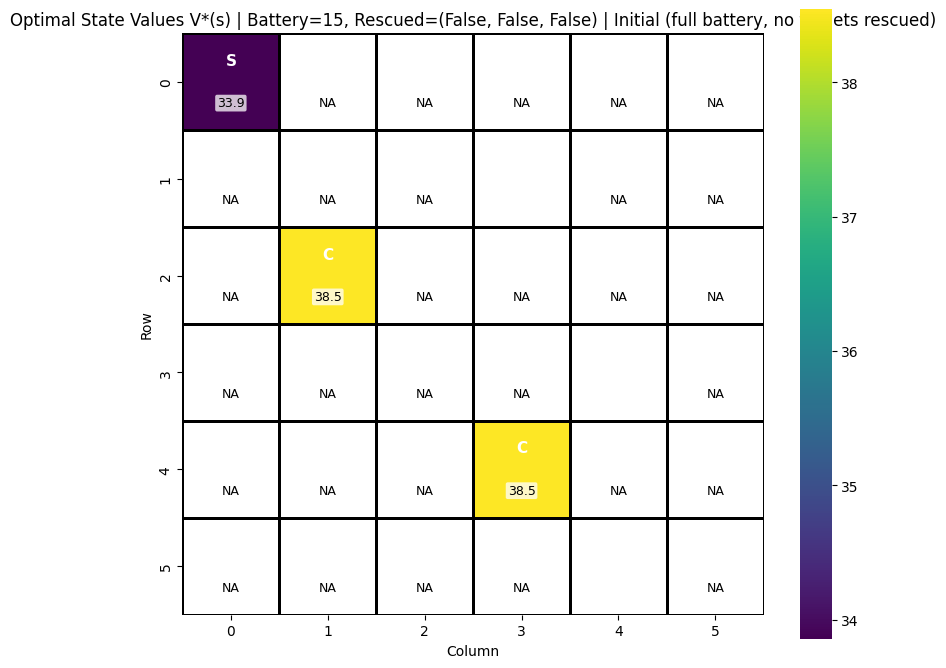


--- State-Value Heatmap (Fixed Battery: 7/15, Rescued Targets: (False, False, False)) ---


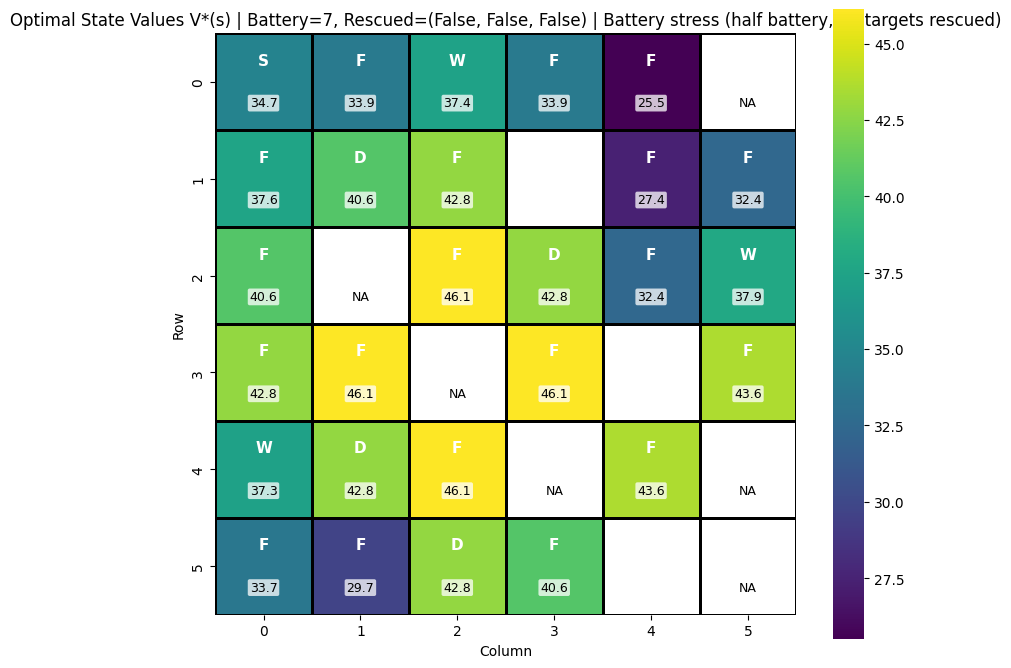

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

HEATMAP_ZONE_GLYPHS = {
    START: "S",
    FREE: "F",
    DANGER: "D",
    RESCUE: "R",
    CHARGE: "C",
    WIND: "W",
    BLOCKED: "X",
}

def plot_state_value_heatmap(env, optimal_V, state_to_idx, fixed_battery, fixed_rescued_targets, title_suffix=""):
    print(f"\n--- State-Value Heatmap (Fixed Battery: {fixed_battery}/{env.max_battery}, Rescued Targets: {fixed_rescued_targets}) ---")

    value_heatmap = np.full(env.grid_size, np.nan)

    for r in range(env.rows):
        for c in range(env.cols):
            if env.initial_grid_config[r, c] == BLOCKED:
                continue
            s = env._get_state_tuple((r, c), fixed_battery, fixed_rescued_targets)
            if s in state_to_idx:
                value_heatmap[r, c] = optimal_V[state_to_idx[s]]
            elif env.is_terminal_state(s):
                value_heatmap[r, c] = 0.0

    plt.figure(figsize=(max(8, env.cols * 1.25), max(6, env.rows * 1.15)))
    ax = sns.heatmap(
        value_heatmap,
        annot=False,
        cmap="viridis",
        cbar=True,
        linewidths=1.0,
        linecolor="black",
        square=True
    )

    title = f"Optimal State Values V*(s) | Battery={fixed_battery}, Rescued={fixed_rescued_targets}"
    if title_suffix:
        title += f" | {title_suffix}"
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")

    for r in range(env.rows):
        for c in range(env.cols):
            cell_type = env.initial_grid_config[r, c]
            if cell_type == BLOCKED:
                ax.text(c + 0.5, r + 0.5, HEATMAP_ZONE_GLYPHS[BLOCKED], ha="center", va="center", color="white", fontsize=12, fontweight="bold")
                continue

            value = value_heatmap[r, c]
            value_text = "NA" if np.isnan(value) else f"{value:.1f}"
            zone_glyph = HEATMAP_ZONE_GLYPHS.get(cell_type, cell_type)

            ax.text(
                c + 0.5, r + 0.28, zone_glyph,
                ha="center", va="center",
                color="white", fontsize=11, fontweight="bold"
            )

            ax.text(
                c + 0.5, r + 0.72, value_text,
                ha="center", va="center",
                color="black", fontsize=9,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.15")
            )

    plt.tight_layout()
    plt.show()

# --- Run State-Value Analysis ---
if __name__ == '__main__':
    try:
        env_dp
        optimal_V
        state_to_idx
    except NameError:
        print("Running DroneRescueEnv and Value Iteration setup again...")
        env_dp = DroneRescueEnv()
        optimal_V, optimal_policy, state_to_idx, idx_to_state, vi_iterations, vi_runtime, vi_final_delta = value_iteration(env_dp)

    num_targets = len(env_dp.rescue_target_locations)
    no_rescued_status = tuple([False] * num_targets)

    full_battery = env_dp.max_battery
    plot_state_value_heatmap(
        env_dp, optimal_V, state_to_idx, full_battery, no_rescued_status,
        title_suffix="Initial (full battery, no targets rescued)"
    )

    half_battery = env_dp.max_battery // 2
    plot_state_value_heatmap(
        env_dp, optimal_V, state_to_idx, half_battery, no_rescued_status,
        title_suffix="Battery stress (half battery, no targets rescued)"
    )

### Heatmap Interpretation

The heatmap color intensity represents the magnitude of the optimal state value V*(s) for each drone position under the fixed slice shown in the title. Brighter cells indicate higher expected long-term return, while darker cells indicate lower-value positions under the optimal policy.

In the initial slice (full battery, no targets rescued), values vary strongly by location because the agent still needs to plan rescue sequence, battery usage, and risk avoidance. Positions that give efficient access to rescue and charging opportunities generally appear with higher values.

In the battery-stress slice (half battery, no targets rescued), many positions become lower-value because the agent has less energy margin to safely reach rescue targets and chargers. This shows how battery scarcity reshapes the value landscape even when rescue status is unchanged.

## DP Scalability Discussion

Now, let's discuss the scalability of Dynamic Programming (DP) for this problem, especially in the context of the "Curse of Dimensionality" and how Deep Reinforcement Learning (DRL) might offer solutions for more complex scenarios, relating it to real-world autonomous drone systems.

### Curse of Dimensionality

The "Curse of Dimensionality" means that as we add state variables, the total number of states grows very quickly. In Dynamic Programming (DP), this is critical because we try to evaluate every state.

In this Drone Rescue MDP, state includes:
1.  **Drone Position:** `(row, col)` -> `rows * cols` possibilities
2.  **Battery Level:** `MAX_BATTERY + 1` possibilities
3.  **Rescue Status Vector:** `2^Num_Targets` possibilities

For group ID 149 (using 5-9 configuration):
- Grid = `6x6` -> `36` positions
- Max battery = `15` -> `16` battery states (`0..15`)
- Rescue targets = `3` -> `2^3 = 8` rescue-status combinations

Approximate state count:
`36 * 16 * 8 = 4608` (before considering action branching and stochastic wind transitions).

How complexity increases further:
- **Grid to 10x10:** position term becomes `100` (nearly 3x increase from 36).
- **More rescue targets:** exponential growth via `2^Num_Targets`.
- **Dynamic weather variables:** each added weather variable multiplies the state space further.

**Is DP sufficient?**

DP is effective for small to moderate finite MDPs where a full model is available. For larger disaster scenarios, DP becomes difficult due to memory and runtime growth.

### Why DP becomes difficult

1.  **Memory pressure:** storing `V(s)` and policy for many states becomes heavy as state count grows.
2.  **Computation cost:** Value Iteration repeatedly sweeps over all states and actions until convergence.
3.  **Model dependence:** DP requires explicit transition probabilities and reward design.
4.  **Discretization limits:** real drone dynamics are continuous and hard to discretize without huge approximation error.

### How Deep RL could help

Deep RL methods use function approximation (neural networks) rather than exact state tables:
- **DQN:** approximates `Q(s,a)` for discrete actions.
- **Actor-Critic / Policy Gradient:** can scale better to richer state representations and partial observability.
- **Generalization:** learned models can act sensibly in unseen states without enumerating all combinations.

### Real-world relevance

Autonomous drones face continuous position/orientation, noisy sensors, moving obstacles, changing weather, and multi-objective trade-offs. In those settings, exact DP is usually not practical, while Deep RL is often a more scalable decision-making framework.

### Dynamic Programming (DP) vs. Deep Reinforcement Learning (DRL) Comparison

| Feature            | Dynamic Programming (DP)                                 | Deep Reinforcement Learning (DRL)                            |
| :----------------- | :------------------------------------------------------- | :----------------------------------------------------------- |
| **State Space**    | Requires discrete, manageable state spaces.              | Can handle high-dimensional, continuous state spaces.        |
| **Action Space**   | Typically discrete.                                      | Can handle both discrete and continuous action spaces.       |
| **Optimality**     | Guaranteed to find the optimal policy for small MDPs.    | Finds a near-optimal policy; optimality not always guaranteed. |
| **Memory Usage**   | High, stores values/policies for every state (lookup table). | Lower, uses neural networks to approximate values/policies.  |
| **Computational Complexity** | High, grows exponentially with state variables.          | High for training, but efficient for inference once trained. |
| **Generalization** | Limited, struggles with unseen states.                   | Excellent, neural networks generalize to unseen states.      |
| **Model Requirement** | Requires a perfect model of the environment (transition probabilities and rewards). | Can learn without an explicit model (model-free) or with a learned model. |
| **Real-world Applicability** | Limited to simple, well-defined problems.                | Essential for complex, real-world problems (e.g., autonomous drones). |
| **Key Challenge**  | Curse of Dimensionality.                                 | Exploration vs. Exploitation, Sample Efficiency, Stability of Training. |
| **Typical Use Cases** | Planning in known, small environments.                   | Complex control tasks, game playing, robotics, autonomous systems. |
| **Approach**       | Iterative computation of value functions or policies across all states. | Uses neural networks for function approximation to learn policies or value functions from experience. |



--- State-Value Heatmap (Fixed Battery: 15/15, Rescued Targets: (False, False, False)) ---


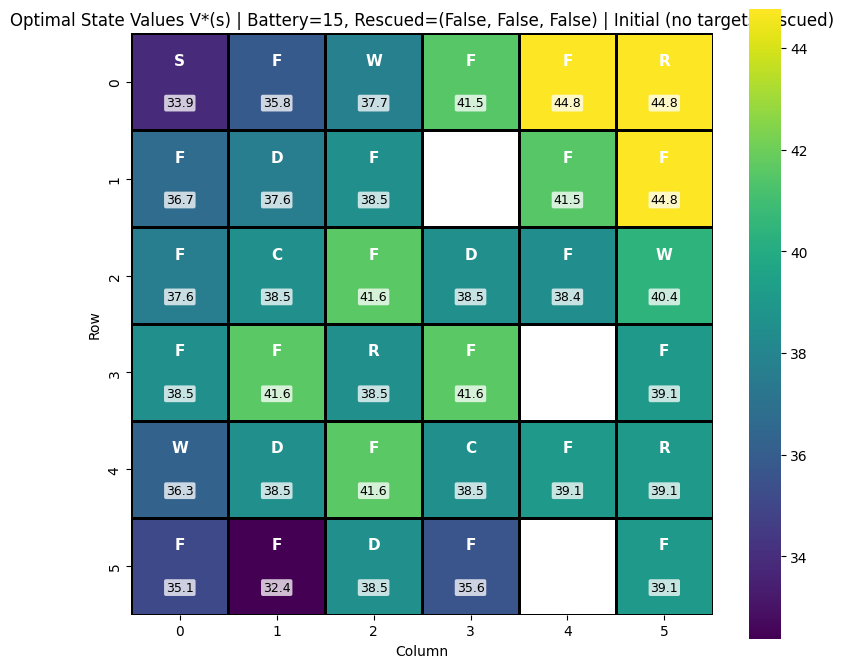


--- State-Value Heatmap (Fixed Battery: 15/15, Rescued Targets: (True, True, True)) ---


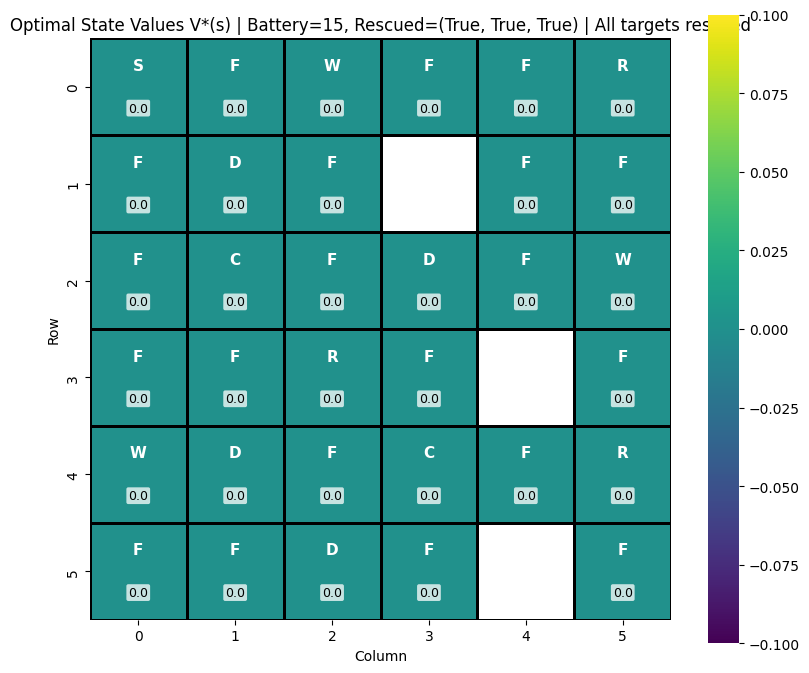

In [ ]:
if __name__ == '__main__':
    try:
        env_dp
        optimal_V
        state_to_idx
    except NameError:
        print("Running DroneRescueEnv and Value Iteration setup again...")
        env_dp = DroneRescueEnv()
        optimal_V, optimal_policy, state_to_idx, idx_to_state, vi_iterations, vi_runtime, vi_final_delta = value_iteration(env_dp)

    num_targets = len(env_dp.rescue_target_locations)
    no_rescued_status = tuple([False] * num_targets)

    full_battery = env_dp.max_battery
    plot_state_value_heatmap(
        env_dp, optimal_V, state_to_idx, full_battery, no_rescued_status,
        title_suffix="Initial (full battery, no targets rescued)"
    )

    half_battery = env_dp.max_battery // 2
    plot_state_value_heatmap(
        env_dp, optimal_V, state_to_idx, half_battery, no_rescued_status,
        title_suffix="Battery stress (half battery, no targets rescued)"
    )